# 05 — Dirichlet Process Survival Model

This notebook implements a Bayesian nonparametric survival model using a Dirichlet Process (DP) mixture.

Motivation:

The parametric models (Exponential, Weibull, Log-normal) impose strong assumptions on the shape of the hazard function. However, the exploratory analysis suggests that the true survival distribution is more flexible.

The Dirichlet Process mixture model allows:

- flexible, data-driven clustering of survival times  
- nonparametric estimation of the survival distribution  
- modeling heterogeneous subpopulations with different risk profiles  

We model survival times using a mixture model:

$$
f(t) = \sum_{k=1}^{\infty} \pi_k f_k(t)
$$

where:

- $\pi_k$ are mixture weights drawn from a Dirichlet Process  
- $f_k(t)$ are component distributions (e.g., Weibull or Log-normal)  

In practice, we approximate this infinite mixture using a truncated representation and perform inference using MCMC.

This notebook focuses on:

1. constructing the likelihood for survival data  
2. handling censoring  
3. implementing a DP mixture model  
4. sampling cluster assignments and parameters  

In [1]:
import os

# Force PyTensor to avoid C compilation and use pure Python mode
os.environ["PYTENSOR_FLAGS"] = "cxx=,mode=FAST_COMPILE,linker=py"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import pymc as pm
import arviz as az
import pytensor.tensor as pt

# Load cleaned survival dataset
data_path = Path("../data/processed/tcga_brca_survival_cleaned.csv")
df = pd.read_csv(data_path)

# Use strictly positive durations for survival likelihoods
df["time_days_adj"] = df["time_days"].copy()
df.loc[df["time_days_adj"] <= 0, "time_days_adj"] = 0.5

print(df.shape)
df.head()

(1095, 10)


,case_id,primary_diagnosis,ajcc_pathologic_stage,demographic.gender,demographic.race,age_at_diagnosis_years,event,time_days,stage_simple,time_days_adj
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,"Infiltrating duct carcinoma, NOS",Stage IA,female,white,60.996578,0.0,337.0,Stage I,337.0
1,0045349c-69d9-4306-a403-c9c1fa836644,Adenoid cystic carcinoma,Stage I,female,white,70.726899,0.0,259.0,Stage I,259.0
2,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,Apocrine adenocarcinoma,Stage IIB,female,white,50.225873,0.0,3102.0,Stage II,3102.0
3,00a2d166-78c9-4687-a195-3d6315c27574,"Infiltrating duct carcinoma, NOS",Stage IIA,female,white,56.709103,0.0,5.0,Stage II,5.0
4,00b11ca8-8540-4a3d-b602-ec754b00230b,"Lobular carcinoma, NOS",Stage IA,female,white,61.593429,0.0,759.0,Stage I,759.0


In [2]:
# Extract survival arrays

T = df["time_days_adj"].values
E = df["event"].values.astype(int)

N = len(T)

print("N =", N)
print("Events =", E.sum())
print("Censored =", (1 - E).sum()) #TODO consider bayesian data imputation

N = 1095
Events = 151
Censored = 944


In [5]:
# Rebuild a numerically stabilized DP survival model

K = 5          # smaller truncation for a pilot run #TODO explain this
eps = 1e-8     # numerical floor

with pm.Model() as dp_survival_model:

    # DP concentration
    alpha = pm.Gamma("alpha", alpha=2.0, beta=1.0)

    # Truncated stick-breaking with final leftover component
    v = pm.Beta("v", alpha=1.0, beta=alpha, shape=K - 1)

    stick_prefix = pt.concatenate([[1.0], pt.extra_ops.cumprod(1.0 - v)])
    pi_main = v * stick_prefix[:-1]
    pi_last = stick_prefix[-1:]
    pi = pm.Deterministic("pi", pt.concatenate([pi_main, pi_last]))

    # Weibull component parameters
    lambda_k_raw = pm.Gamma("lambda_k_raw", alpha=1.0, beta=0.001, shape=K)
    rho_k_raw = pm.Gamma("rho_k_raw", alpha=2.0, beta=1.0, shape=K)

    lambda_k = pt.clip(lambda_k_raw, eps, np.inf)
    rho_k = pt.clip(rho_k_raw, eps, np.inf)

    # Observed data
    t_obs = pt.clip(pt.as_tensor_variable(T), eps, np.inf)
    e_obs = pt.as_tensor_variable(E)

    # Stable log density / log survival for Weibull
    log_t = pt.log(t_obs)[:, None]
    log_lambda = pt.log(lambda_k)[None, :]
    z = (t_obs[:, None] / lambda_k[None, :]) ** rho_k[None, :]

    log_f = (
        pt.log(rho_k)[None, :]
        - log_lambda
        + (rho_k[None, :] - 1.0) * (log_t - log_lambda)
        - z
    )

    log_S = -z

    component_loglik = e_obs[:, None] * log_f + (1 - e_obs)[:, None] * log_S

    # Stable mixture log-likelihood
    log_pi = pt.log(pt.clip(pi, eps, 1.0))[None, :]
    log_mix = pm.math.logsumexp(log_pi + component_loglik, axis=1)

    pm.Potential("likelihood", log_mix.sum())

# Pilot Run

In [7]:
# Pilot subset for faster debugging

df_pilot = df.sample(n=250, random_state=733).copy()

T = df_pilot["time_days_adj"].values
E = df_pilot["event"].values.astype(int)

N = len(T)

print("Pilot N =", N)
print("Events =", E.sum())
print("Censored =", (1 - E).sum())

Pilot N = 250
Events = 42
Censored = 208


In [8]:
# Rebuild the stabilized DP survival model on the pilot subset

K = 5
eps = 1e-8

with pm.Model() as dp_survival_model:

    alpha = pm.Gamma("alpha", alpha=2.0, beta=1.0)

    v = pm.Beta("v", alpha=1.0, beta=alpha, shape=K - 1)

    stick_prefix = pt.concatenate([[1.0], pt.extra_ops.cumprod(1.0 - v)])
    pi_main = v * stick_prefix[:-1]
    pi_last = stick_prefix[-1:]
    pi = pm.Deterministic("pi", pt.concatenate([pi_main, pi_last]))

    lambda_k_raw = pm.Gamma("lambda_k_raw", alpha=1.0, beta=0.001, shape=K)
    rho_k_raw = pm.Gamma("rho_k_raw", alpha=2.0, beta=1.0, shape=K)

    lambda_k = pt.clip(lambda_k_raw, eps, np.inf)
    rho_k = pt.clip(rho_k_raw, eps, np.inf)

    t_obs = pt.clip(pt.as_tensor_variable(T), eps, np.inf)
    e_obs = pt.as_tensor_variable(E)

    log_t = pt.log(t_obs)[:, None]
    log_lambda = pt.log(lambda_k)[None, :]
    z = (t_obs[:, None] / lambda_k[None, :]) ** rho_k[None, :]

    log_f = (
        pt.log(rho_k)[None, :]
        - log_lambda
        + (rho_k[None, :] - 1.0) * (log_t - log_lambda)
        - z
    )

    log_S = -z

    component_loglik = e_obs[:, None] * log_f + (1 - e_obs)[:, None] * log_S

    log_pi = pt.log(pt.clip(pi, eps, 1.0))[None, :]
    log_mix = pm.math.logsumexp(log_pi + component_loglik, axis=1)

    pm.Potential("likelihood", log_mix.sum())

In [9]:
# Short pilot posterior run

with dp_survival_model:
    trace = pm.sample(
        draws=150,
        tune=150,
        chains=1,
        cores=1,
        target_accept=0.9,
        random_seed=733,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [alpha, v, lambda_k_raw, rho_k_raw]


Output()

Sampling 1 chain for 150 tune and 150 draw iterations (150 + 150 draws total) took 213 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


In [10]:
# Posterior summary for key DP mixture parameters

az.summary(
    trace,
    var_names=["alpha", "pi", "lambda_k_raw", "rho_k_raw"],
    round_to=3
)

arviz - WARNING - Shape validation failed: input_shape: (1, 150), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.848,0.409,0.199,1.612,0.041,0.031,98.690,130.553,NaN
pi[0],0.906,0.096,0.734,0.997,0.012,0.013,54.590,57.516,NaN
pi[1],0.054,0.076,0.000,0.210,0.009,0.014,79.572,60.696,NaN
pi[2],0.022,0.044,0.000,0.079,0.005,0.010,63.982,66.938,NaN
pi[3],0.009,0.016,0.000,0.033,0.002,0.004,32.594,86.866,NaN
pi[4],0.008,0.013,0.000,0.036,0.001,0.001,56.714,74.087,NaN
lambda_k_raw[0],4894.200,571.169,3937.243,6063.831,42.228,37.870,182.237,113.068,NaN
lambda_k_raw[1],1428.595,1324.114,14.301,3900.280,134.226,156.780,68.984,49.532,NaN
lambda_k_raw[2],1182.562,1055.799,3.805,3157.872,113.311,74.371,74.672,67.490,NaN
lambda_k_raw[3],1232.942,1092.883,81.329,3484.761,130.062,94.245,57.554,106.430,NaN


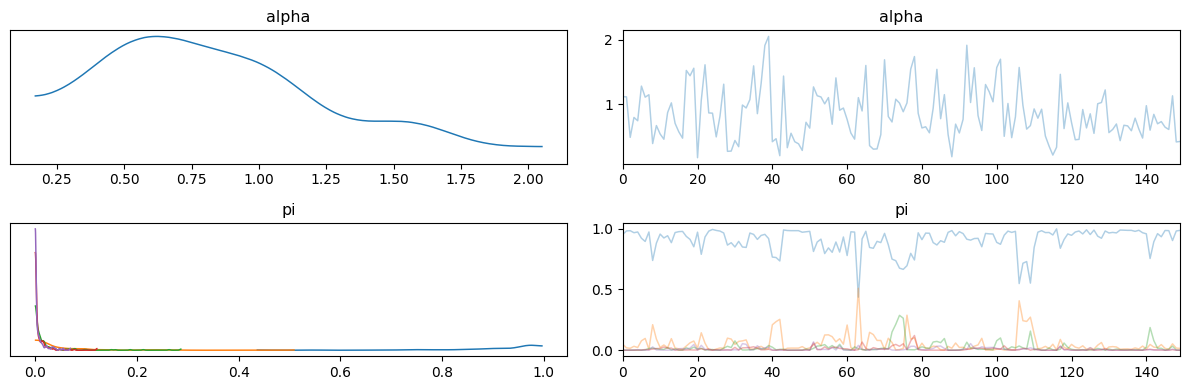

In [11]:
# Trace plots for key parameters

az.plot_trace(trace, var_names=["alpha", "pi"])
plt.tight_layout()
plt.show()

In [12]:
# Posterior mean of mixture weights

pi_mean = trace.posterior["pi"].mean(dim=("chain", "draw")).values

for i, w in enumerate(pi_mean):
    print(f"Component {i}: {w:.4f}")

Component 0: 0.9064
Component 1: 0.0537
Component 2: 0.0224
Component 3: 0.0091
Component 4: 0.0084


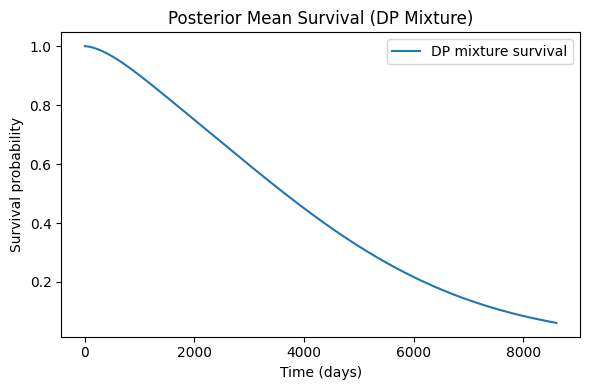

In [13]:
# Posterior mean survival curve from DP mixture

# Extract posterior means
lambda_mean = trace.posterior["lambda_k_raw"].mean(dim=("chain", "draw")).values
rho_mean = trace.posterior["rho_k_raw"].mean(dim=("chain", "draw")).values

t_grid = np.linspace(1, df["time_days"].max(), 200)

S_dp = np.zeros_like(t_grid)

for k in range(len(pi_mean)):
    S_k = np.exp(-(t_grid / lambda_mean[k]) ** rho_mean[k])
    S_dp += pi_mean[k] * S_k

# Plot
plt.figure(figsize=(6,4))
plt.plot(t_grid, S_dp, label="DP mixture survival")

plt.xlabel("Time (days)")
plt.ylabel("Survival probability")
plt.title("Posterior Mean Survival (DP Mixture)")

plt.legend()
plt.tight_layout()
plt.show()

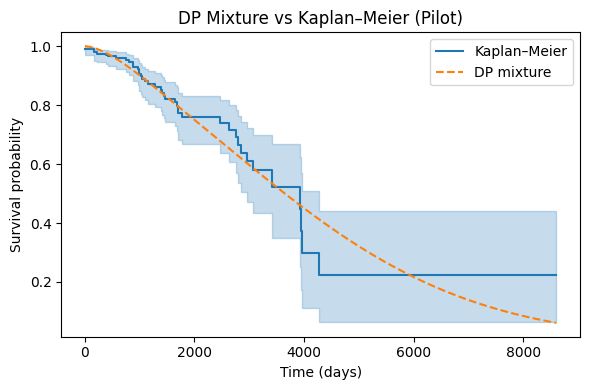

In [14]:
# Compare DP survival vs Kaplan–Meier

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df_pilot["time_days"], event_observed=df_pilot["event"])

plt.figure(figsize=(6,4))

# KM
kmf.plot_survival_function(label="Kaplan–Meier")

# DP
plt.plot(t_grid, S_dp, label="DP mixture", linestyle="--")

plt.xlabel("Time (days)")
plt.ylabel("Survival probability")
plt.title("DP Mixture vs Kaplan–Meier (Pilot)")

plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Save posterior trace for reuse in later notebooks
import arviz as az
from pathlib import Path

output_dir = Path("../data/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

az.to_netcdf(trace, output_dir / "dp_survival_trace_pilot.nc")

print("Trace saved.")

Trace saved.
